In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from sklearn.decomposition import PCA
header = "data/"

In [2]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [3]:
def Lorentzian(freq, amp, const, center, k):
    return const + amp*k**2/((freq-center)**2 + k**2)

In [5]:
data = "/2025-08-12/2025-08-12T083525_db4f2035-b00_spectrum"
dd_tx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_tx = dd_tx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_tx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_e = dd_tx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_eg_div_tx = s11_e / s11_g

data = "/2025-08-12/2025-08-12T083656_1167cc1c-b00_spectrum"
dd_rx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_rx = dd_rx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_rx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_e = dd_rx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_eg_div_rx = s11_e / s11_g

In [6]:
def s11_ge_dp(f, f_r, f_f, k_ex, k_in, chi, g, gamma, phi):
    k_tot = k_ex + k_in
    s11_g = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-f_r) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-f_r)-gamma/2) + g**2)
    s11_e = np.cos(phi) + np.exp(1j*phi) * k_ex * (1j*(f-(f_r+chi)) - gamma/2)/((1j*(f-f_f)-k_tot/2) * (1j*(f-(f_r+chi))-gamma/2) + g**2)
    return (s11_e/s11_g).conj()
def s11_ge(f, f_r, k_ex, k_in, chi, phi, a0):
    s11_g = np.cos(phi) + np.exp(1j*phi) *(1j*(f-f_r)+(k_ex-k_in)/2)/(1j*(f-f_r)-(k_ex+k_in)/2)
    s11_e = np.cos(phi) + np.exp(1j*phi) *(1j*(f-(f_r+chi))+(k_ex-k_in)/2)/(1j*(f-(f_r+chi))-(k_ex+k_in)/2)
    return (s11_e/s11_g).conj() + a0

def guess_params(data,x):
    par_ini = {"f_r":9.343e9, "k_ex": 10e6, "k_in":10e6, "chi":-5e6, "phi":np.pi/2, "a0":3,}
    par_max = {"f_r":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "phi":np.pi,"a0":np.inf,}
    par_min = {"f_r":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf,"phi":-np.pi,"a0":-np.inf,}
    par_vary = {"f_r":1,"k_ex":1, "k_in":1, "chi":1, "phi":0, "a0":1,}
    return par_ini,par_max,par_min,par_vary
def guess_params_dp(data,x):
    par_ini = {"f_r":9.346e9, "f_f":9.340e9, "k_ex": 138e6, "k_in":1e6, "chi":-5e6, "g":64e6, "gamma":0, "phi":0,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":1, "k_ex":1, "k_in":0, "chi":1, "g":1, "gamma":0, "phi":0}
    return par_ini,par_max,par_min,par_vary

def probe_resonator_fit(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # ???
            min=par_min[name],  # ???
            max=par_max[name],  # ???
            vary=par_vary[name] # ?????????????
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result
def probe_resonator_fit_dp(data, x):
    import lmfit as lmf
    model = lmf.Model(s11_ge_dp, nan_policy='omit')
    params = model.make_params()
    par_ini,par_max,par_min,par_vary=guess_params_dp(data,x)
    for name in params:
        params[name].set(
            value=par_ini[name],  # ???
            min=par_min[name],  # ???
            max=par_max[name],  # ???
            vary=par_vary[name] # ?????????????
        )
    result=model.fit(data, f=x, params=params, method='leastsq')
    return result

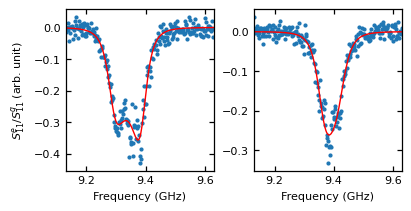

In [10]:
# result = probe_resonator_fit(s11_eg_div, freq)
result_tx = probe_resonator_fit_dp(s11_eg_div_tx, freq_tx)
result_rx = probe_resonator_fit_dp(s11_eg_div_rx, freq_rx)

fig, ax = plt.subplots(1, 2, figsize=(4,2), constrained_layout=True)

# plt.title("g-e transition")
ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# result.plot_fit(ax = ax)
ax[0].plot(freq_tx*1e-9, np.angle(s11_eg_div_tx), 'o')
ax[0].plot(freq_tx*1e-9, np.angle(result_tx.best_fit), c="red", lw=1.0)
ax[0].set_xlabel("Frequency (GHz)")
ax[0].set_ylabel(r"$S_{11}^e/S_{11}^g$ (arb. unit)")
ax[0].set_xlim(freq_tx[0]*1e-9, freq_tx[-1]*1e-9)

ax[1].plot(freq_rx*1e-9, np.angle(s11_eg_div_rx), 'o')
ax[1].plot(freq_rx*1e-9, np.angle(result_rx.best_fit), c="red", lw=1.0)
ax[1].set_xlabel("Frequency (GHz)")
ax[1].set_xlim(freq_tx[0]*1e-9, freq_tx[-1]*1e-9)
# plt.plot(freq, np.angle(result.init_fit))
# plt.xlim(9.365e9, 9.375e9)
# plt.ylim(-0.45, 0.25)
plt.show()

result_tx
result_rx

In [11]:
data = "/2025-08-11/2025-08-11T144757_bbcaab25-b00_spectrum"
dd_tx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_tx = dd_tx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_tx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_e = dd_tx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_tx))
s11_eg_div_tx = s11_e / s11_g

data = "/2025-08-11/2025-08-11T224630_9619bb96-b00_spectrum"
dd_rx = datadict_from_hdf5(header + data +"/data")
ed = 0#1e-9/9/(10.25-10)

freq_rx = dd_rx['probe_frequency']['values']*1e9
# s11_eg = dd['s11_eg']['values']* np.exp(1j*(ed*2*np.pi*freq))
s11_g = dd_rx['s11_g']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_e = dd_rx['s11_e']['values']* np.exp(1j*(ed*2*np.pi*freq_rx))
s11_eg_div_rx = s11_e / s11_g

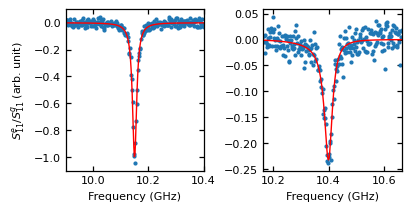

In [13]:
# result = probe_resonator_fit(s11_eg_div, freq)
def guess_params_dp(data,x):
    par_ini = {"f_r":10.148e9, "f_f":10.138e9, "k_ex": 33e6, "k_in":1e6, "chi":-4.3e6, "g":43e6, "gamma":0, "phi":0,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":0, "k_ex":1, "k_in":1, "chi":1, "g":1, "gamma":0, "phi":0}
    return par_ini,par_max,par_min,par_vary
result_tx = probe_resonator_fit_dp(s11_eg_div_tx, freq_tx)
def guess_params_dp(data,x):
    par_ini = {"f_r":10.414e9, "f_f":10.405e9, "k_ex":38e6, "k_in":0.002e9, "chi":-6.5e6, "g":45e6, "gamma":0, "phi":-0.01,}
    par_max = {"f_r":np.inf, "f_f":np.inf, "k_ex":np.inf, "k_in":np.inf, "chi":0, "g":np.inf, "gamma":np.inf, "phi":np.pi,}
    par_min = {"f_r":0, "f_f":0, "k_ex":0, "k_in":0e-3, "chi":-np.inf, "g":0, "gamma":0, "phi":-np.pi,}
    par_vary = {"f_r":1, "f_f":1, "k_ex":1, "k_in":0, "chi":1, "g":1, "gamma":0, "phi":0}
    return par_ini,par_max,par_min,par_vary
result_rx = probe_resonator_fit_dp(1/s11_eg_div_rx, freq_rx)

fig, ax = plt.subplots(1, 2, figsize=(4,2), constrained_layout=True)

# plt.title("g-e transition")
ax[0].tick_params(axis="both", direction="in")
ax[0].tick_params(top=True, bottom=True, left=True, right=True)
ax[1].tick_params(axis="both", direction="in")
ax[1].tick_params(top=True, bottom=True, left=True, right=True)
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# result.plot_fit(ax = ax)
ax[0].plot(freq_tx*1e-9, np.angle(s11_eg_div_tx), 'o')
ax[0].plot(freq_tx*1e-9, np.angle(result_tx.best_fit), c="red", lw=1.0)
ax[0].set_xlabel("Frequency (GHz)")
ax[0].set_ylabel(r"$S_{11}^e/S_{11}^g$ (arb. unit)")
ax[0].set_xlim(freq_tx[0]*1e-9, freq_tx[-1]*1e-9)

ax[1].plot(freq_rx*1e-9, np.angle(1/s11_eg_div_rx), 'o')
ax[1].plot(freq_rx*1e-9, np.angle(result_rx.best_fit), c="red", lw=1.0)
ax[1].set_xlabel("Frequency (GHz)")
ax[1].set_xlim(freq_rx[0]*1e-9, freq_rx[-1]*1e-9)
# plt.plot(freq, np.angle(result.init_fit))
# plt.xlim(9.365e9, 9.375e9)
# plt.ylim(-0.45, 0.25)
plt.show()

result_tx
result_rx